In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from docutils.nodes import classifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, r2_score
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score


In [3]:
csv = "C:\\Users\\user\\Documents\\bank_fraud.csv"
df = pd.read_csv(csv)

In [4]:
df.head(4)

,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,...,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type
0,TXN0000000001,CUST00121959,2023-08-17,21:13:00,21,0,0,USA,London,Grocery,...,39.49,157,23,52.7,10.20,0,0,0,0,NaN
1,TXN0000000002,CUST00146868,2024-02-06,05:16:00,5,0,1,UK,New York,Healthcare,...,153.71,153,23,0.9,12.47,0,0,0,0,NaN
2,TXN0000000003,CUST00131933,2024-06-28,12:15:00,12,0,0,Canada,Delhi,Grocery,...,118.20,161,20,9.2,0.08,0,1,0,0,NaN
3,TXN0000000004,CUST00103695,2023-03-16,02:53:00,2,0,1,France,Tokyo,Utilities,...,49.50,160,25,14.8,17.94,1,0,1,1,Synthetic Identity


**EXPLORING THE DATA**

In [5]:
df.shape

(1000000, 26)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 26 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   transaction_id            1000000 non-null  object 
 1   customer_id               1000000 non-null  object 
 2   transaction_date          1000000 non-null  object 
 3   transaction_time          1000000 non-null  object 
 4   hour_of_day               1000000 non-null  int64  
 5   is_weekend                1000000 non-null  int64  
 6   is_night_transaction      1000000 non-null  int64  
 7   country                   1000000 non-null  object 
 8   city                      1000000 non-null  object 
 9   merchant_category         1000000 non-null  object 
 10  payment_method            1000000 non-null  object 
 11  device_type               1000000 non-null  object 
 12  customer_age              1000000 non-null  int64  
 13  credit_score              10

In [7]:
print(df.describe())
my_cols = df.columns.tolist()
print('\nThe Columns are: \n',df.columns.tolist())

print('\nStandard Deviation for Trx Amount: ', df['transaction_amount'].std())


          hour_of_day      is_weekend  is_night_transaction    customer_age  \
count  1000000.000000  1000000.000000        1000000.000000  1000000.000000   
mean        11.496978        0.286022              0.375057       41.771678   
std          6.923751        0.451900              0.484138       13.424588   
min          0.000000        0.000000              0.000000       18.000000   
25%          5.000000        0.000000              0.000000       32.000000   
50%         11.000000        0.000000              0.000000       42.000000   
75%         18.000000        1.000000              1.000000       51.000000   
max         23.000000        1.000000              1.000000       85.000000   

         credit_score  account_age_years  account_balance  transaction_amount  \
count  1000000.000000     1000000.000000    1000000.00000      1000000.000000   
mean       679.028781           4.987911      16594.25442          204.724665   
std         78.828748           4.925949     

In [8]:
print(df.isna)

<bound method DataFrame.isna of        transaction_id   customer_id transaction_date transaction_time  \
0       TXN0000000001  CUST00121959       2023-08-17         21:13:00   
1       TXN0000000002  CUST00146868       2024-02-06         05:16:00   
2       TXN0000000003  CUST00131933       2024-06-28         12:15:00   
3       TXN0000000004  CUST00103695       2023-03-16         02:53:00   
4       TXN0000000005  CUST00119880       2024-07-12         12:39:00   
...               ...           ...              ...              ...   
999995  TXN0000999996  CUST00176672       2022-11-18         21:15:00   
999996  TXN0000999997  CUST00005742       2021-07-03         22:57:00   
999997  TXN0000999998  CUST00108137       2021-08-12         07:37:00   
999998  TXN0000999999  CUST00117141       2021-06-07         07:09:00   
999999  TXN0001000000  CUST00117401       2021-01-07         18:43:00   

        hour_of_day  is_weekend  is_night_transaction country        city  \
0             

In [9]:
df.isnull().sum()

transaction_id                   0
customer_id                      0
transaction_date                 0
transaction_time                 0
hour_of_day                      0
is_weekend                       0
is_night_transaction             0
country                          0
city                             0
merchant_category                0
payment_method                   0
device_type                      0
customer_age                     0
credit_score                     0
account_age_years                0
account_balance                  0
transaction_amount               0
num_prev_transactions            0
transaction_freq_monthly         0
distance_from_home_km            0
time_since_last_txn_hrs          0
is_international                 0
failed_attempts                  0
pin_changed_recently             0
is_fraud                         0
fraud_type                  944745
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
if df.duplicated().sum() > 0:
    print('Some data are Duplicated')
    df.drop_duplicates()
else:
    print('No Duplicates')

No Duplicates


In [12]:
#Notice that in our dataset we have transaction time in a date format which our model can not read, so we convert it to a date our model can read

df['transaction_date'] = pd.to_datetime(df['transaction_date'], format = '%Y-%m-%d')

#Extracting useful informations from the transaction dtate and creating new columns with them
#Transaction Year >>>
df['transaction_year'] = df['transaction_date'].dt.year

#Transaction Month >>>
df['transaction_month'] = df['transaction_date'].dt.month

#Transaction Day >>>
df['transaction_day'] = df['transaction_date'].dt.day

print(df.columns)

Index(['transaction_id', 'customer_id', 'transaction_date', 'transaction_time',
       'hour_of_day', 'is_weekend', 'is_night_transaction', 'country', 'city',
       'merchant_category', 'payment_method', 'device_type', 'customer_age',
       'credit_score', 'account_age_years', 'account_balance',
       'transaction_amount', 'num_prev_transactions',
       'transaction_freq_monthly', 'distance_from_home_km',
       'time_since_last_txn_hrs', 'is_international', 'failed_attempts',
       'pin_changed_recently', 'is_fraud', 'fraud_type', 'transaction_year',
       'transaction_month', 'transaction_day'],
      dtype='object')


**MATPLOTLIB**

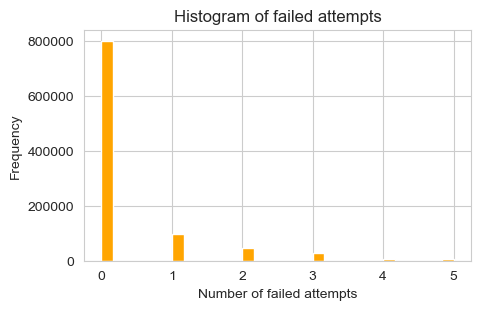

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize= (5,3))
plt.hist(df['failed_attempts'], bins=30, color = 'orange')
plt.title('Histogram of failed attempts')
plt.xlabel('Number of failed attempts')
plt.ylabel('Frequency')
plt.show()


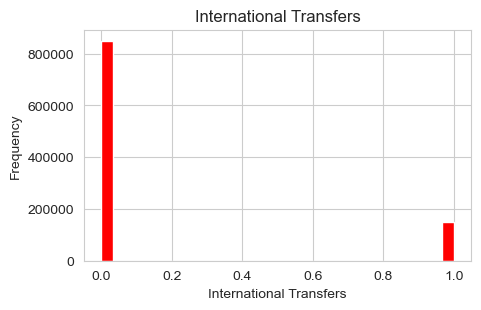

In [14]:
plt.figure(figsize= (5, 3))
plt.title("International Transfers")
plt.hist(df['is_international'], bins= 30, color = 'red')
plt.xlabel('International Transfers')
plt.ylabel('Frequency')
plt.show()

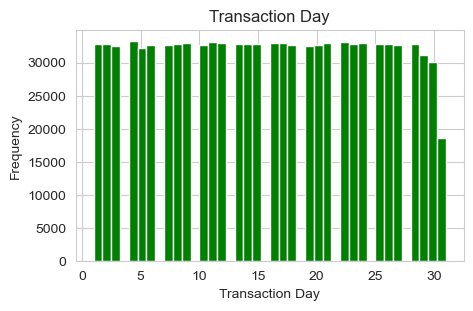

In [15]:
plt.figure(figsize=(5, 3))
plt.title('Transaction Day')
plt.hist(df['transaction_day'], bins= 40, color = 'green')
plt.xlabel('Transaction Day')
plt.ylabel('Frequency')
plt.show()

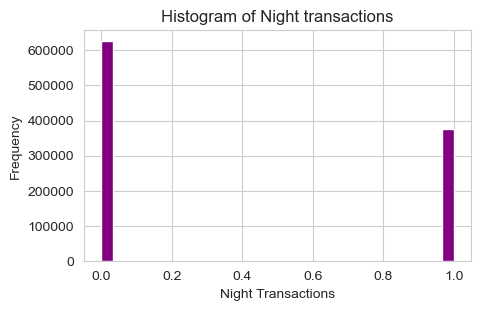

Where 1 stands for TRUE and 0 stands for FALSE


In [16]:
plt.figure(figsize= (5, 3))
plt.title('Histogram of Night transactions')
plt.hist(df['is_night_transaction'], bins = 30, color = 'purple')
plt.xlabel('Night Transactions')
plt.ylabel('Frequency')
plt.show()

print('Where 1 stands for TRUE and 0 stands for FALSE')

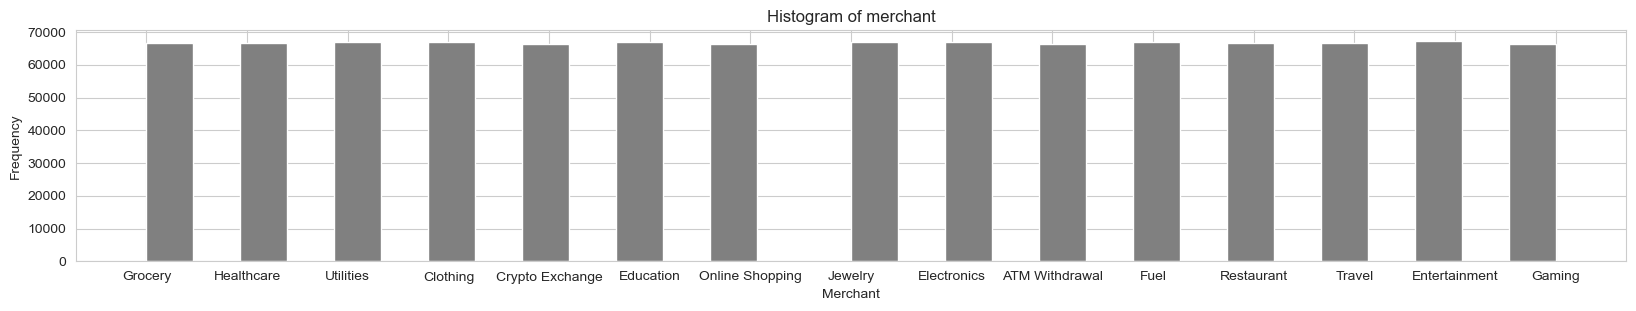

In [17]:
plt.figure(figsize= (20, 3))
plt.title('Histogram of merchant')
plt.hist(df['merchant_category'], bins = 30, color = 'grey')
plt.xlabel('Merchant')
plt.ylabel('Frequency')
plt.show()

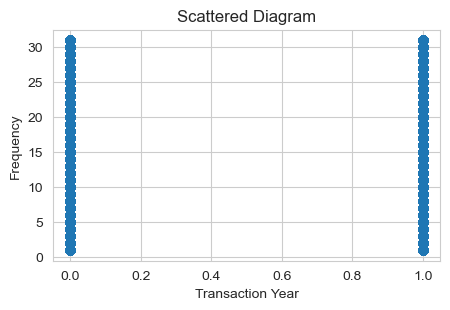

In [18]:
plt.figure(figsize= (5,3))
plt.title('Scattered Diagram')
plt.scatter(df['is_fraud'], df['transaction_day'])
plt.xlabel('Transaction Year')
plt.ylabel('Frequency')
plt.show()

In [20]:
len(df.columns.tolist())
df['is_fraud'].value_counts()

is_fraud
0    944745
1     55255
Name: count, dtype: int64

In [22]:
df.head(2)

,transaction_id,customer_id,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,payment_method,...,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type,transaction_year,transaction_month,transaction_day
0,TXN0000000001,CUST00121959,21:13:00,21,0,0,USA,London,Grocery,Bank Transfer,...,52.7,10.20,0,0,0,0,NaN,2023,8,17
1,TXN0000000002,CUST00146868,05:16:00,5,0,1,UK,New York,Healthcare,Cheque,...,0.9,12.47,0,0,0,0,NaN,2024,2,6


**USING PIE CHART TO LOOK AT THE DATA TO VISUALIZE THE DATA WELL TO SEE WHICH ONE IS NOT FRAUD OR FRAUD**

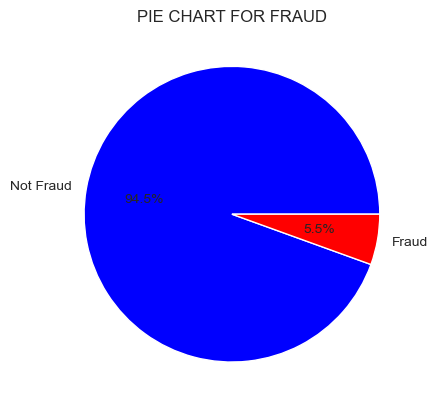

In [23]:
value_counts = df['is_fraud'].value_counts() #Arugument for the pie chart function

label = ['Not Fraud', 'Fraud'] #Second argument for the pie function


plt.title('PIE CHART FOR FRAUD')
plt.pie(value_counts, labels = label, autopct = "%1.1f%%", colors = ['blue', 'red'])
plt.show()

**SEABORN**

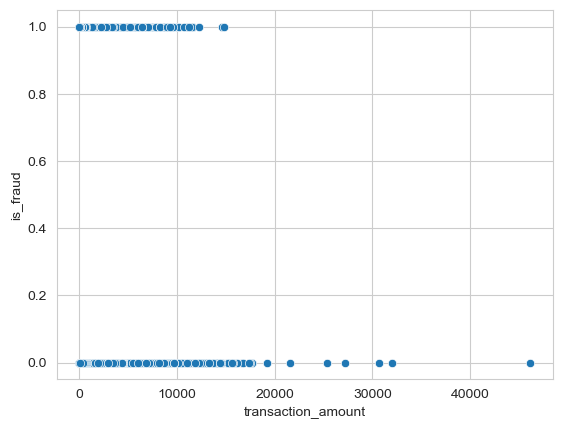

In [24]:
sns.scatterplot(data = df, x = 'transaction_amount', y = 'is_fraud')

plt.show()

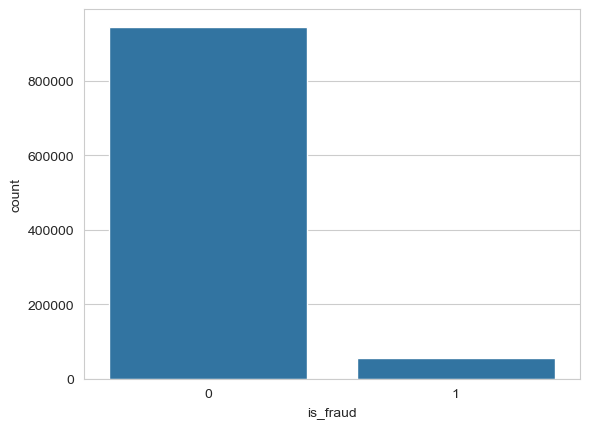

In [25]:
sns.countplot(data= df,
              x = 'is_fraud')

plt.show()

**DROPPING THE UNNECESSARY COLUMNS**

In [26]:
try:
    df = df.drop(['transaction_id', 'customer_id'], axis = 1)
    print('Columns have been deleted')
except Exception as e:
    print (e)

Columns have been deleted


In [30]:
try:
    df = df.drop(['transaction_date'], axis = 1)
    print('Columns (Trx Date) have been deleted')
except Exception as e:
    print (e)

"['transaction_date'] not found in axis"


In [31]:
try:
    df = df.drop(['fraud_type'], axis = 1)
    print('Column for fraud type have been deleted')
except Exception as e:
    print (e)

"['fraud_type'] not found in axis"


In [32]:
df.head(2)

,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,payment_method,device_type,customer_age,...,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,transaction_year,transaction_month,transaction_day
0,21:13:00,21,0,0,USA,London,Grocery,Bank Transfer,POS Terminal,18,...,23,52.7,10.20,0,0,0,0,2023,8,17
1,05:16:00,5,0,1,UK,New York,Healthcare,Cheque,Desktop,30,...,23,0.9,12.47,0,0,0,0,2024,2,6


**TRAINING THE MODEL FIRSTLY BY SPLIT TRAIN-TEST**

In [33]:
df.columns.tolist()

['transaction_time',
 'hour_of_day',
 'is_weekend',
 'is_night_transaction',
 'country',
 'city',
 'merchant_category',
 'payment_method',
 'device_type',
 'customer_age',
 'credit_score',
 'account_age_years',
 'account_balance',
 'transaction_amount',
 'num_prev_transactions',
 'transaction_freq_monthly',
 'distance_from_home_km',
 'time_since_last_txn_hrs',
 'is_international',
 'failed_attempts',
 'pin_changed_recently',
 'is_fraud',
 'transaction_year',
 'transaction_month',
 'transaction_day']

In [38]:
print(df.head(5))

     transaction_time  hour_of_day  is_weekend  is_night_transaction country  \
0 1900-01-01 21:13:00           21           0                     0     USA   
1 1900-01-01 05:16:00            5           0                     1      UK   
2 1900-01-01 12:15:00           12           0                     0  Canada   
3 1900-01-01 02:53:00            2           0                     1  France   
4 1900-01-01 12:39:00           12           0                     0  Canada   

        city merchant_category payment_method   device_type  customer_age  \
0     London           Grocery  Bank Transfer  POS Terminal            18   
1   New York        Healthcare         Cheque       Desktop            30   
2      Delhi           Grocery         Crypto        Mobile            20   
3      Tokyo         Utilities     Debit Card        Mobile            29   
4  Melbourne          Clothing     Debit Card       Desktop            49   

   ...  transaction_freq_monthly  distance_from_home_km 

In [35]:
df['transaction_time'] = pd.to_datetime(df['transaction_time'], format = '%H:%M:%S') #Changing the format of the column to a datetime format

In [39]:
df['transaction_hour'] = df['transaction_time'].dt.hour #Adding only the hour from the datetime format of the transaction time column

In [40]:
df['transaction_min'] = df['transaction_time'].dt.minute #Adding only the minutes from the datetime format of the transaction time column

In [41]:
#df = df.drop(['transaction_period'], axis = 1) #Dropping

In [42]:
df= df.drop(['transaction_time'], axis = 1)

In [43]:
df.columns

Index(['hour_of_day', 'is_weekend', 'is_night_transaction', 'country', 'city',
       'merchant_category', 'payment_method', 'device_type', 'customer_age',
       'credit_score', 'account_age_years', 'account_balance',
       'transaction_amount', 'num_prev_transactions',
       'transaction_freq_monthly', 'distance_from_home_km',
       'time_since_last_txn_hrs', 'is_international', 'failed_attempts',
       'pin_changed_recently', 'is_fraud', 'transaction_year',
       'transaction_month', 'transaction_day', 'transaction_hour',
       'transaction_min'],
      dtype='object')

**SEPARATING THE X AND THE Y**

In [75]:
categorical_features = ['merchant_category']

x = df[['hour_of_day', 'is_night_transaction',
       'merchant_category',
       'transaction_amount',
       'time_since_last_txn_hrs', 'is_international', 'failed_attempts',
       'pin_changed_recently', 'transaction_hour']]

#OR x= df.drop(['is_fraud'], axis = 1)>>>>> The shorter version

y = df['is_fraud']

In [76]:
len(x.columns.tolist())

9

In [77]:
df.dtypes



hour_of_day                   int64
is_weekend                    int64
is_night_transaction          int64
country                      object
city                         object
merchant_category            object
payment_method               object
device_type                  object
customer_age                  int64
credit_score                  int64
account_age_years           float64
account_balance             float64
transaction_amount          float64
num_prev_transactions         int64
transaction_freq_monthly      int64
distance_from_home_km       float64
time_since_last_txn_hrs     float64
is_international              int64
failed_attempts               int64
pin_changed_recently          int64
is_fraud                      int64
transaction_year              int32
transaction_month             int32
transaction_day               int32
transaction_hour              int32
transaction_min               int32
dtype: object

**TRAIN SPLIT**

In [78]:
#x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42) this meant to be used but due to the data imbalance we are going to be adding the stratify = y when spliting the data. What does startify do, It makes sure that the same proportion of each class is present in both the training and test sets.

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y)

**PREPROCESSING**

In [79]:
#Preprocessing the model by checking for columns with objects or string values in our columns and encoding them to coded numbers.>>>>>>>>>>>>>>>>>>
preprocessor = ColumnTransformer(transformers = [('cat', OneHotEncoder(handle_unknown= 'ignore'), categorical_features)], remainder = 'passthrough')

# The model variable is meant to be this>>>> but due to the data imbalance, we have to pass another argument of class_weight to be = 'balanced', and also changed n_estimator from 50 to 200 and also added max_depth to 10, to make the model learn more, #my_model = Pipeline(steps = [('preprocessor', preprocessor), ('classifier', RandomForestClassifier(n_estimators = 50, random_state = 42))])
my_model = Pipeline(steps = [('preprocessor', preprocessor), ('classifier', RandomForestClassifier(n_estimators = 200, random_state = 42, class_weight= 'balanced', max_depth= 10))])


**TRAINING THE MODEL PROPER**

In [80]:
my_model.fit(x_train, y_train)
predictions = my_model.predict(x_test)

In [98]:
X_train_encoded = preprocessor.fit_transform(x_train)

X_train_encoded.shape

(800000, 23)

In [99]:
acc_score = accuracy_score(y_test, predictions)
prec_score = precision_score(y_test, predictions)
rec = recall_score(y_test, predictions)
f_scores = f1_score(y_test, predictions)

print('Accuracy Evaluation Metrics: ', acc_score)
print('\nPrecision Score Evaluation Metrics: ', prec_score)
print("\nRecall Evaluation Metrics: ", rec)
print("\nF1 Evaluation Metrics:" , f_scores)

print('\nClassification Report: ', classification_report(y_test, predictions))

Accuracy Evaluation Metrics:  0.583205

Precision Score Evaluation Metrics:  0.09046216583597644

Recall Evaluation Metrics:  0.7226495339788255

F1 Evaluation Metrics: 0.1607957233894756

Classification Report:                precision    recall  f1-score   support

           0       0.97      0.58      0.72    188949
           1       0.09      0.72      0.16     11051

    accuracy                           0.58    200000
   macro avg       0.53      0.65      0.44    200000
weighted avg       0.92      0.58      0.69    200000



In [100]:
predictions[:20]

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0])

In [101]:
predictions[:101] #Checking the first possible predictions of our model

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0])

In [113]:
len(df.columns.tolist())

26

In [47]:
y_train.value_counts()

is_fraud
0    755796
1     44204
Name: count, dtype: int64

In [48]:
y_test.value_counts()

is_fraud
0    188949
1     11051
Name: count, dtype: int64

In [43]:
print(confusion_matrix(y_test, predictions))

[[112755  76194]
 [  3353   7698]]


In [44]:
print(np.unique(predictions, return_counts=True)) #Checking the numpy unique predictions.

(array([0, 1]), array([116108,  83892]))


In [45]:
df['is_fraud'].value_counts() * 0.2

is_fraud
0    188949.0
1     11051.0
Name: count, dtype: float64

In [107]:
print(df['is_fraud'].unique())

[0 1]


In [108]:
x_train.shape

(800000, 25)

In [48]:
y_train.value_counts()

is_fraud
0    755796
1     44204
Name: count, dtype: int64

In [49]:
print(np.unique(predictions, return_counts=True))

(array([0, 1]), array([116108,  83892]))


In [118]:
XTest_probability34 = my_model.predict_proba(x_test)[0, 1]

print(XTest_probability34)

[0.48804672 0.51195328]


In [113]:
XTRAIN_PROB= my_model.predict_proba(x_train)[0, 1]
print(XTRAIN_PROB)

0.2965335938934063


**TESTING THE MODEL WITH DIFFERENT INPUTS**

In [51]:
new_transaction = pd.DataFrame({
    'hour_of_day': [5],
    'is_weekend': [0],
    'is_night_transaction': [0],
    'country': ['Nigeria'],
    'city': ['Lagos'],
    'merchant_category': ['Electronics'],
    'payment_method': ['Crypto'],
    'device_type': ['Mobile'],
    'customer_age': [56],
    'credit_score': [550],
    'account_age_years': [8],
    'account_balance': [5000],
    'transaction_amount': [4500],
    'num_prev_transactions': [6],
    'transaction_freq_monthly': [1],
    'distance_from_home': [112],
    'is_international': [0],
    'failed_attempts': [0],
    'time_since_last_txn_hrs': [0.5],
    'pin_changed_recently': [0],
    'transaction_hour': [5],
    'transaction_min': [15],
    'distance_from_home_km': [50],
    'transaction_year': [2020],
    'transaction_day': [11],
    'transaction_month': [12]
})

In [106]:
predict = my_model.predict(new_transaction)[0]  #Telling the program to run and give me the FIRST probability prediction only without the list format. In other words, it is extracting the output from the array.
print(predict)

0


In [122]:
probability = my_model.predict_proba(new_transaction)[0, 1] #Telling the program to run and give me the first probablility prediction using the [0] indexing fmt on the Fraud Axis[1].

In [124]:
answer_prob = probability

print(f'SYSTEM PREDICTION RESPONSE: {'Fraud' if predict == 1 else 'Not Fraud'} ')
print(f'SYSTEM RESPONSE: Fraud Probability {probability:.2%}%')


SYSTEM PREDICTION RESPONSE: Not Fraud 
SYSTEM RESPONSE: Fraud Probability 45.63%%


In [125]:
predict2 = my_model.predict(new_transaction)

In [126]:
if predict2 == [1]:
    print('This is a Fradulent Transaction')
elif predict2 == [0]:
    print('This is a Legitimate Transaction')

else:
    print('....')


This is a Legitimate Transaction


In [95]:
my_model.feature_names_in_

array(['hour_of_day', 'is_night_transaction', 'merchant_category',
       'transaction_amount', 'time_since_last_txn_hrs',
       'is_international', 'failed_attempts', 'pin_changed_recently',
       'transaction_hour'], dtype=object)

In [127]:
print(predict2)

[0]


In [102]:
import joblib

joblib.dump(my_model, 'my_fraud_detection_model.pkl')
print('Saved Sucessfully!!!!!!!')

Saved Sucessfully!!!!!!!


In [96]:
print(x_train.columns)

Index(['hour_of_day', 'is_night_transaction', 'merchant_category',
       'transaction_amount', 'time_since_last_txn_hrs', 'is_international',
       'failed_attempts', 'pin_changed_recently', 'transaction_hour'],
      dtype='object')


In [139]:
my_model.predict_proba(new_transaction)[0, 0]

np.float64(0.5436884776605191)

In [143]:
df['is_fraud'].unique()


array([0, 1])

In [53]:
MODEL_IMPORTANCE_COUNT = my_model[-1]

In [56]:
FEATURES_FROM_TRANSFORMER = my_model.named_steps['preprocessor'].get_feature_names_out()

In [58]:
print(MODEL_IMPORTANCE_COUNT)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)


In [61]:
print(MODEL_IMPORTANCE_COUNT.feature_importances_) #Features importance for the training of the model

[0.00048654 0.00060358 0.00061226 0.00064883 0.00064183 0.00085103
 0.00055991 0.00057855 0.00069144 0.00090649 0.00056681 0.00050255
 0.00048692 0.00062043 0.00053342 0.00067754 0.00056591 0.00059699
 0.00057225 0.00054164 0.00056274 0.00053323 0.00050123 0.00056447
 0.00052611 0.00059468 0.00053485 0.00049453 0.00061611 0.00052697
 0.02938209 0.00094716 0.02834322 0.00148268 0.00105435 0.00127848
 0.00106316 0.00093246 0.00119437 0.00176096 0.03054788 0.00152786
 0.00123862 0.00145756 0.00166029 0.00077662 0.00052424 0.00083201
 0.0006333  0.00081776 0.00073786 0.00075635 0.00088569 0.00089923
 0.00075829 0.00067748 0.07319713 0.0008924  0.11932666 0.00689572
 0.01147895 0.00749526 0.00916119 0.0121779  0.00740805 0.005988
 0.00837033 0.04250256 0.14550145 0.30130891 0.02711948 0.00267326
 0.00407327 0.00610922 0.07193476 0.00651571]


In [63]:
DATAFRAME_FOR_IMPORTANCE = pd.DataFrame({
    'Feature': FEATURES_FROM_TRANSFORMER,
    'Importance To Training': MODEL_IMPORTANCE_COUNT.feature_importances_
}).sort_values(by='Importance To Training', ascending=False #Creating a dataframe with the list of the features and their importance

In [81]:
DATAFRAME_FOR_IMPORTANCE.count(axis = 0)

Feature                   76
Importance To Training    76
dtype: int64

In [93]:
print(DATAFRAME_FOR_IMPORTANCE.head(38))

                                   Feature  Importance To Training
69              remainder__failed_attempts                0.301309
68             remainder__is_international                0.145501
58         remainder__is_night_transaction                0.119327
56                  remainder__hour_of_day                0.073197
74             remainder__transaction_hour                0.071935
67      remainder__time_since_last_txn_hrs                0.042503
40          cat__merchant_category_Jewelry                0.030548
30   cat__merchant_category_ATM Withdrawal                0.029382
32  cat__merchant_category_Crypto Exchange                0.028343
70         remainder__pin_changed_recently                0.027119
63           remainder__transaction_amount                0.012178
60                 remainder__credit_score                0.011479
62              remainder__account_balance                0.009161
66        remainder__distance_from_home_km                0.00

In [94]:
print(DATAFRAME_FOR_IMPORTANCE.tail(36))

                               Feature  Importance To Training
49      cat__payment_method_Debit Card                0.000818
45   cat__payment_method_Bank Transfer                0.000777
54       cat__device_type_POS Terminal                0.000758
51                cat__device_type_ATM                0.000756
50  cat__payment_method_Mobile Payment                0.000738
8                      cat__country_UK                0.000691
15                      cat__city_Lyon                0.000678
55             cat__device_type_Tablet                0.000677
3                  cat__country_France                0.000649
4                 cat__country_Germany                0.000642
48          cat__payment_method_Crypto                0.000633
13                    cat__city_London                0.000620
28                   cat__city_Toronto                0.000616
2                  cat__country_Canada                0.000612
1                  cat__country_Brazil                0